In [2]:
#carregar o arquivo de treino
import gdown
file_id = "1iZt3Ja6vLiTbY7Gf5iFq0spDuyUHrTCC"
url = f"https://drive.google.com/uc?id={file_id}"
output = "train.xlsx"  # nome local no Colab
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1iZt3Ja6vLiTbY7Gf5iFq0spDuyUHrTCC
To: /content/train.xlsx
100%|██████████| 7.62M/7.62M [00:00<00:00, 77.7MB/s]


'train.xlsx'

In [16]:
#analise dos dados
import pandas as pd
df = pd.read_excel("/content/train.xlsx")
print(df.head(10))
print(f"\nQuantidade de dados: {len(df)}")
textos_duplicados = df.groupby('resp_text')['clarity'].nunique()
print(f"Dados repetidos {len(df) - len(textos_duplicados)}")
textos_com_conflito = textos_duplicados[textos_duplicados > 1].index
print(f"Textos com mais de uma classificação: {len(textos_com_conflito)}")
print(f"Quantidade de dados por classe {df['clarity'].value_counts()}")


                                           resp_text clarity
0   Prezado(a) Senhor(a),   Esclarecemos que o Se...      c5
1   Prezada cidadã,  As informações sobre óbitos ...      c1
2   Prezado Senhor Julio,  A Ouvidoria-Geral da P...      c1
3   Prezado(a) Senhor(a),   Esclarecemos que o Se...    c234
4   Senhor, O Serviço de Informações ao Cidadão d...    c234
5   Prezado, para ter acesso às informações solic...      c1
6   Prezado Sr.,  Informamos que a UFPE dispõe de...    c234
7   Prezado (a) Senhor (a),  Em resposta ao seu p...    c234
8   Prezada Angélica,      Anexo encontra-se docu...      c1
9   Prezado Sr. Felipe  Cumprimentando-o cordialm...    c234

Quantidade de dados: 20092
Dados repetidos 1660
Textos com mais de uma classificação: 291
Quantidade de dados por classe clarity
c5      6892
c234    6853
c1      6347
Name: count, dtype: int64


# Baseline - Modelo com TF-IDF e Regressão Logística

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

df['resp_text'] = df['resp_text'].astype(str)
X = df.resp_text
Y = df.clarity

x_train_text, x_test_text, y_train, y_test = train_test_split( df.resp_text, Y, test_size=0.2, random_state=123, stratify=Y)

vetor = TfidfVectorizer()

x_train = vetor.fit_transform(x_train_text)

x_test = vetor.transform(x_test_text)


clf = LogisticRegression( C=10.0, penalty='l2', solver='liblinear', max_iter=500)

clf.fit(x_train, y_train)

predicted = clf.predict(x_test)

score = f1_score(y_test, predicted, average='macro')

accuracy = accuracy_score(y_test, predicted)

print(f"Acurácia: {accuracy}")
print(f"F1-score: {score}")

Acurácia: 0.46205523762129885
F1-score: 0.4609681991930558


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/669 [00:00<?, ?it/s]


Variância explicada (2 componentes): 12.23%
  - Componente 1: 6.63%
  - Componente 2: 5.60%


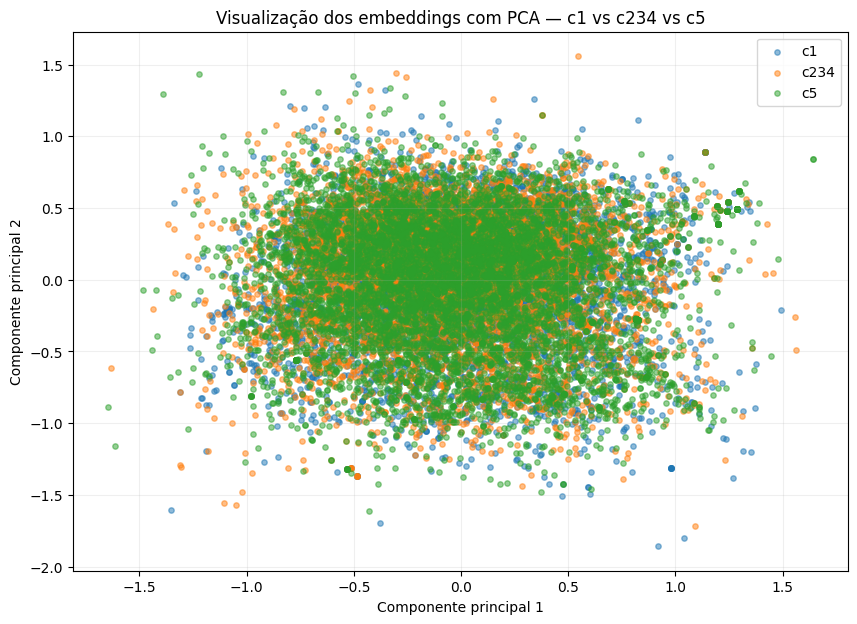

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA


# ---------------------------------------------------------------------------
# Configurações
# ---------------------------------------------------------------------------
RANDOM_STATE = 42

MODELO_EMBEDDING = "paraphrase-multilingual-MiniLM-L12-v2"
PALAVRAS_POR_CHUNK = 90   # mesmo valor usado no pipeline original

# Agora uma lista, em vez de duas variáveis fixas
CLASSES = ["c1", "c234", "c5"]   # ajuste aqui para as classes que quiser comparar


def dividir_em_chunks(texto, palavras_por_chunk=PALAVRAS_POR_CHUNK):
    """Quebra o texto em pedaços de N palavras, para não estourar o limite do modelo."""
    palavras = texto.split()
    if len(palavras) == 0:
        return [""]
    return [
        " ".join(palavras[i:i + palavras_por_chunk])
        for i in range(0, len(palavras), palavras_por_chunk)
    ]


def embedding_documento_completo(textos, modelo_embedding, batch_size=64):
    """
    Para cada texto: quebra em chunks, embeda cada chunk, e faz a MÉDIA
    dos embeddings dos chunks -> um único vetor representando o texto inteiro.
    """
    todos_chunks = []
    indice_documento = []

    for i, texto in enumerate(textos):
        chunks = dividir_em_chunks(texto)
        todos_chunks.extend(chunks)
        indice_documento.extend([i] * len(chunks))

    embeddings_chunks = modelo_embedding.encode(
        todos_chunks, show_progress_bar=True, batch_size=batch_size
    )

    indice_documento = np.array(indice_documento)
    dim = embeddings_chunks.shape[1]
    embeddings_documento = np.zeros((len(textos), dim), dtype="float32")

    for i in range(len(textos)):
        embeddings_documento[i] = embeddings_chunks[indice_documento == i].mean(axis=0)

    return embeddings_documento


# ---------------------------------------------------------------------------
# 1. Carregar os dados e filtrar as classes desejadas
# ---------------------------------------------------------------------------
df = pd.read_excel("/content/train.xlsx")
df["resp_text"] = df["resp_text"].astype(str)

x_textos = df["resp_text"].tolist()
y_labels = df["clarity"].tolist()


# ---------------------------------------------------------------------------
# 2. Gerar embeddings
# ---------------------------------------------------------------------------
modelo_embedding = SentenceTransformer(MODELO_EMBEDDING)
x_emb = embedding_documento_completo(x_textos, modelo_embedding)


# ---------------------------------------------------------------------------
# 3. PCA
# ---------------------------------------------------------------------------
pca = PCA(n_components=2, random_state=RANDOM_STATE)
x_pca = pca.fit_transform(x_emb)

print(
    f"\nVariância explicada (2 componentes): "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)
print(f"  - Componente 1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - Componente 2: {pca.explained_variance_ratio_[1]:.2%}")


# ---------------------------------------------------------------------------
# 4. Visualização
# ---------------------------------------------------------------------------
y_labels_arr = np.array(y_labels)

plt.figure(figsize=(10, 7))

for classe in CLASSES:
    mascara = y_labels_arr == classe
    plt.scatter(
        x_pca[mascara, 0],
        x_pca[mascara, 1],
        label=classe,
        alpha=0.5,
        s=15,
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title(f"Visualização dos embeddings com PCA — {' vs '.join(CLASSES)}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [5]:

import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset
from torch.nn import CrossEntropyLoss


# ---------------------------------------------------------------------------
# Configurações
# ---------------------------------------------------------------------------
TEST_SIZE = 0.2
RANDOM_STATE = 42

MODELO_BASE = "neuralmind/bert-base-portuguese-cased"
MAX_LENGTH = 256          # tokens por texto (cobre boa parte da mediana/90º percentil de palavras)
NUM_EPOCHS = 4
BATCH_SIZE = 8            # ajuste conforme a memória da GPU (Colab: Runtime > Change runtime type > GPU)
LEARNING_RATE = 2e-5


def carregar_dados():
    df = pd.read_excel("/content/train.xlsx")
    df['resp_text'] = df['resp_text'].astype(str)

    coluna_alvo = "clarity"

    n_por_texto = df.groupby("resp_text")[coluna_alvo].nunique()
    conflitantes = n_por_texto[n_por_texto > 1].index
    df = df[~df["resp_text"].isin(conflitantes)].copy()

    df = df.drop_duplicates(subset=['resp_text', coluna_alvo])

    x_textos = df['resp_text'].tolist()

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df[coluna_alvo])

    return x_textos, y_encoded, label_encoder


class TextDataset(Dataset):
    """Dataset simples que tokeniza sob demanda (texto -> ids do BERT)."""

    def __init__(self, textos, labels, tokenizer, max_length):
        self.textos = textos
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.textos[idx],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


class TrainerComPesoDeClasse(Trainer):
    """Trainer customizado para usar CrossEntropyLoss com class_weight (desbalanceamento)."""

    def __init__(self, pesos_classe, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pesos_classe = pesos_classe

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = CrossEntropyLoss(weight=self.pesos_classe.to(logits.device))
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }


if __name__ == "__main__":
    x_textos, y_encoded, label_encoder = carregar_dados()
    n_classes = len(label_encoder.classes_)

    x_train, x_val, y_train, y_val = train_test_split(
        x_textos, y_encoded, test_size=TEST_SIZE, stratify=y_encoded, random_state=RANDOM_STATE
    )

    tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)
    modelo = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, num_labels=n_classes)

    dataset_train = TextDataset(x_train, y_train, tokenizer, MAX_LENGTH)
    dataset_val = TextDataset(x_val, y_val, tokenizer, MAX_LENGTH)

    pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    pesos_classe = torch.tensor(pesos, dtype=torch.float)

    training_args = TrainingArguments(
        output_dir="./resultados_bert",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        report_to="none"
    )

    trainer = TrainerComPesoDeClasse(
        pesos_classe=pesos_classe,
        model=modelo,
        args=training_args,
        train_dataset=dataset_train,
        eval_dataset=dataset_val,
        compute_metrics=compute_metrics
    )

    trainer.train()

    resultado = trainer.predict(dataset_val)
    y_pred_val = np.argmax(resultado.predictions, axis=1)

    print(f"\nAccuracy: {accuracy_score(y_val, y_pred_val):.4f}")
    print(f"F1-score (macro): {f1_score(y_val, y_pred_val, average='macro'):.4f}")

    print("\nMatriz de confusão:")
    print(f"Classes na ordem: {list(label_encoder.classes_)}")
    print(confusion_matrix(y_val, y_pred_val))

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Accuracy: 0.4635
F1-score (macro): 0.4625

Matriz de confusão:
Classes na ordem: ['c1', 'c234', 'c5']
[[582 309 212]
 [398 452 396]
 [266 366 648]]
